<h1 style="color:#56B4E9;">Week 8 — Day 1</h1>

<h2 style="color:#0072B2;">Sprint 3 Planning & NLP Preprocessing</h2>

### IMDB Sentiment Analysis — Continuing the Week 7 Experiment

During Week 7, the IMDB dataset was used to compare an LSTM, pretrained DistilBERT, TF-IDF with Logistic Regression, and a weighted ensemble.

Therefore, this notebook does not treat IMDB as a new dataset. It reuses the same data split and studies a new question:

> **How does task-aware text preprocessing affect the representations used by classical and deep-learning models?**

The notebook builds two reusable text versions:

- `minimal_text` for LSTM and transformer pipelines.
- `classical_text` for TF-IDF and traditional machine-learning models.

The key principle is that preprocessing must match the model. More cleaning is not always better.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Define the Sprint 3 goal and backlog using the Week 7 results.
- Reconstruct the exact Week 7 training, validation, and test split.
- Audit duplicates and normalized-text overlap.
- Explain word and sub-word tokenization using real tokenizers.
- Build minimal and classical preprocessing pipelines.
- Preserve sentiment-critical negation words.
- Compare stemming with POS-aware lemmatization.
- Measure how preprocessing changes length and vocabulary size.
- Save reproducible training, validation, and test datasets for Day 2.

<h2 style="color:#0072B2;">1.1 Sprint 2 Handoff</h2>

Week 7 produced the following IMDB results:

| Previous experiment | Test F1 | Main lesson |
|---|---:|---|
| Text LSTM | `0.7950` | A sequential model can learn sentiment from limited data. |
| Pretrained DistilBERT | `0.8152` | Language pretraining improved classification quality. |
| TF-IDF + Logistic Regression | `0.8617` | A simple lexical baseline was extremely competitive. |
| Final weighted ensemble | `0.8939` | Lexical and contextual models made complementary errors. |

These results become the starting point for Sprint 3. Day 1 will prepare consistent input variants so that Day 2 can measure whether preprocessing actually improves the TF-IDF baseline.

<span style="color:#D55E00;"><b>Fair-comparison rule:</b></span>  
The same Week 7 split must be reused. Otherwise, a score change could be caused by different reviews rather than different preprocessing.

<h2 style="color:#0072B2;">1.2 Sprint 3 Goal and Backlog</h2>

<span style="color:#009E73;"><b>Sprint 3 Goal:</b></span>  
Turn the Week 7 sentiment models into a reproducible end-to-end system with model-specific preprocessing, fair comparison, error analysis, and explainability.

### Sprint 3 Backlog

1. Reconstruct and verify the Week 7 split.
2. Build reusable minimal and classical preprocessing functions.
3. Compare TF-IDF and embeddings on the same validation metric.
4. Keep training-time and prediction-time preprocessing identical.
5. Integrate preprocessing and prediction into one function.
6. Evaluate the final pipeline once on the untouched test set.
7. Analyze false positives and false negatives.
8. Apply SHAP explainability where appropriate.

### Day 1 Acceptance Criteria

- No duplicates remain inside the source pools.
- Training, validation, and test sets remain separate.
- Negation survives the classical cleaning pipeline.
- No cleaned review is missing or empty.
- Three reusable output files are created for Day 2.

<h2 style="color:#0072B2;">1.3 Experimental Design</h2>

One cleaning strategy should not be forced onto every model.

| Text version | Processing | Intended models |
|---|---|---|
| `text` | Original review | Inspection and traceability |
| `minimal_text` | HTML cleanup, lowercase, whitespace normalization | LSTM and DistilBERT |
| `classical_text` | Negation expansion, punctuation removal, task-aware stop-word removal, POS-aware lemmatization | TF-IDF and Logistic Regression |

Transformers should receive language that remains close to natural text because their pretrained tokenizer and embeddings already model syntax and context. Classical TF-IDF can benefit from stronger normalization because it treats terms as lexical features.

In [1]:
%pip install -q datasets nltk transformers scikit-learn tqdm

from pathlib import Path
from collections import Counter
import html
import random
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

for resource in [
    "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
    "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
]:
    nltk.download(resource, quiet=True)

print("Environment prepared successfully.")
print("Pandas version:", pd.__version__)
print("NLTK version:", nltk.__version__)

Note: you may need to restart the kernel to use updated packages.
Environment prepared successfully.
Pandas version: 3.0.3
NLTK version: 3.10.3


<h3 style="color:#009E73;">Environment Preparation</h3>

The experiment uses:

- Hugging Face Datasets to load IMDB.
- Scikit-learn to reproduce the Week 7 split.
- NLTK for word tokenization, stop words, POS tagging, stemming, and lemmatization.
- A real DistilBERT tokenizer to demonstrate sub-word tokenization.
- Pandas, Matplotlib, and Seaborn for auditing and visualization.

The random seed remains `42`, matching Week 7.

<h2 style="color:#0072B2;">1.4 Reconstructing the Week 7 Split</h2>

The same Week 7 procedure is reproduced:

1. Load the official IMDB training and test sets.
2. Remove exact duplicate reviews from each source pool.
3. Select `5,000` development reviews from the official training set.
4. Split them into `4,000` training and `1,000` validation reviews.
5. Select `1,000` reviews from the official test set.

The final experiment therefore uses:

$$4{,}000\;train + 1{,}000\;validation + 1{,}000\;test$$

The validation set is used for decisions. The test set is reserved for one final evaluation.

In [2]:
imdb = load_dataset("stanfordnlp/imdb")

full_train_df = imdb["train"].to_pandas()[["text", "label"]]
full_test_df = imdb["test"].to_pandas()[["text", "label"]]

training_source = full_train_df.drop_duplicates(subset="text").reset_index(drop=True)
test_source = full_test_df.drop_duplicates(subset="text").reset_index(drop=True)

development_df, _ = train_test_split(
    training_source,
    train_size=5000,
    random_state=SEED,
    stratify=training_source["label"],
)

train_df, validation_df = train_test_split(
    development_df,
    test_size=1000,
    random_state=SEED,
    stratify=development_df["label"],
)

test_df, _ = train_test_split(
    test_source,
    train_size=1000,
    random_state=SEED,
    stratify=test_source["label"],
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

label_names = {0: "Negative", 1: "Positive"}
for dataframe in [train_df, validation_df, test_df]:
    dataframe["sentiment"] = dataframe["label"].map(label_names)

split_summary = pd.DataFrame([
    {
        "Split": name,
        "Samples": len(dataframe),
        "Negative": int((dataframe["label"] == 0).sum()),
        "Positive": int((dataframe["label"] == 1).sum()),
    }
    for name, dataframe in [
        ("Training", train_df),
        ("Validation", validation_df),
        ("Test", test_df),
    ]
])

display(split_summary)
assert split_summary["Samples"].tolist() == [4000, 1000, 1000]

,Split,Samples,Negative,Positive
0,Training,4000,1997,2003
1,Validation,1000,499,501
2,Test,1000,498,502


<h3 style="color:#009E73;">Split Interpretation</h3>

This split reproduces the Week 7 experiment, so future score differences can be attributed to representation or preprocessing rather than different samples.

The official test source remains separate from the official training source. Duplicate removal occurs before sampling, preventing repeated reviews inside each source pool.

<h2 style="color:#0072B2;">1.5 Data Integrity Audit</h2>

Exact duplicates were removed before sampling. A second audit checks whether reviews become identical after basic normalization.

This is important because two reviews may differ only in capitalization, HTML tags, or repeated spaces. If normalized copies appear in different splits, evaluation may become optimistic.

In [3]:
def normalize_for_overlap(text):
    text = html.unescape(str(text)).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", text).strip()


normalized_sets = {
    "Train": set(train_df["text"].map(normalize_for_overlap)),
    "Validation": set(validation_df["text"].map(normalize_for_overlap)),
    "Test": set(test_df["text"].map(normalize_for_overlap)),
}

integrity_report = pd.DataFrame([
    {"Check": "Train duplicates", "Value": train_df["text"].duplicated().sum()},
    {"Check": "Validation duplicates", "Value": validation_df["text"].duplicated().sum()},
    {"Check": "Test duplicates", "Value": test_df["text"].duplicated().sum()},
    {"Check": "Train-validation overlap", "Value": len(normalized_sets["Train"] & normalized_sets["Validation"])},
    {"Check": "Train-test overlap", "Value": len(normalized_sets["Train"] & normalized_sets["Test"])},
    {"Check": "Validation-test overlap", "Value": len(normalized_sets["Validation"] & normalized_sets["Test"])},
])

display(integrity_report)
assert integrity_report.iloc[:3]["Value"].sum() == 0

if integrity_report.iloc[3:]["Value"].sum() == 0:
    print("No normalized-text overlap was detected.")
else:
    print("Warning: normalized-text overlap was detected and must be reviewed.")

,Check,Value
0,Train duplicates,0
1,Validation duplicates,0
2,Test duplicates,0
3,Train-validation overlap,0
4,Train-test overlap,1
5,Validation-test overlap,0


<h2 style="color:#0072B2;">1.6 Inspecting Raw Reviews</h2>

Raw IMDB reviews may include:

- HTML tags such as `<br />`.
- Capitalization differences.
- Punctuation and numerical ratings.
- Contractions such as `wasn't`.
- Repeated spaces.
- Common words with limited lexical value.

These elements are not automatically useless. For example, `3/10`, repeated exclamation marks, and negation may carry sentiment. Cleaning decisions must therefore be documented rather than applied blindly.

In [4]:
example_indices = [
    train_df.index[train_df["label"] == 0][0],
    train_df.index[train_df["label"] == 1][0],
]

for number, index in enumerate(example_indices, start=1):
    print(f"--- Raw Example {number}: {train_df.loc[index, 'sentiment']} ---")
    print(train_df.loc[index, "text"][:900])
    print()

--- Raw Example 1: Negative ---
There have been many movies featuring Bigfoot, the majority of which are not good but most at least have a goofy charm to them. Sasquatch Hunters doesn't even have that going for it. It's just a crashing bore.<br /><br />Sasquatch Hunters is about a group of paleontologists, primatologists, and forest rangers that venture off into a remote part of a Pacific Northwest forest. Bones belonging to some sort of abnormally large primate have been discovered in this region and since apes aren't natural to North America to begin with this leads to a scientific expedition. Sure enough, they soon discover a whole burial ground full of the skeletal remains of these enormous ape-like creatures. I think we all know what happens to people that disturb ancient burial grounds in the movies.<br /><br />The first half of the movie consists of uninteresting, interchangeable characters assembling their gear

--- Raw Example 2: Positive ---
This light hearted comedy should b

<h2 style="color:#0072B2;">1.7 Word and Sub-word Tokenization</h2>

Tokenization splits text into processable units.

### Word Tokenization

NLTK separates a sentence into words and punctuation. It is useful before classical linguistic preprocessing.

### Sub-word Tokenization

DistilBERT uses WordPiece tokenization. A rare word may be divided into known pieces, while common words may remain whole.

A transformer's actual tokenizer must be used instead of manually guessing how a word will be split.

In [5]:
tokenization_example = (
    "The movie was not great, and the ending was uncharacteristically predictable!"
)

word_tokens = word_tokenize(tokenization_example)
distilbert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
subword_tokens = distilbert_tokenizer.tokenize(tokenization_example)

print("Original text:")
print(tokenization_example)
print("\nNLTK word tokens:")
print(word_tokens)
print("\nDistilBERT sub-word tokens:")
print(subword_tokens)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original text:
The movie was not great, and the ending was uncharacteristically predictable!

NLTK word tokens:
['The', 'movie', 'was', 'not', 'great', ',', 'and', 'the', 'ending', 'was', 'uncharacteristically', 'predictable', '!']

DistilBERT sub-word tokens:
['the', 'movie', 'was', 'not', 'great', ',', 'and', 'the', 'ending', 'was', 'un', '##cha', '##rac', '##ter', '##istic', '##ally', 'predictable', '!']


<h3 style="color:#009E73;">Tokenization Interpretation</h3>

The NLTK output is intended for the classical pipeline. The DistilBERT output follows the vocabulary learned during pretraining.

The word `not` must remain visible because it changes the meaning of `great`. The transformer's tokenizer will later process `minimal_text`; the NLTK tokenizer will process `classical_text`.

<h2 style="color:#0072B2;">1.8 Two Levels of Cleaning</h2>

### Minimal Cleaning

$$Raw \rightarrow HTML\ removal \rightarrow lowercase \rightarrow whitespace\ normalization$$

This version preserves punctuation, numbers, word order, and most natural-language structure.

### Classical Cleaning

$$Minimal \rightarrow negation\ expansion \rightarrow punctuation\ removal$$

$$\rightarrow tokenization \rightarrow task\text{-}aware\ stop\ words \rightarrow lemmatization$$

This version reduces lexical variation for TF-IDF. Negation is expanded before punctuation removal so that `wasn't` becomes `was not` instead of `wasn t`.

In [6]:
cleaning_example = "This Movie wasn't GOOD!!! <br /> I rated it 3/10."

html_removed = re.sub(r"<[^>]+>", " ", html.unescape(cleaning_example))
lowercased = html_removed.lower()
negation_expanded = re.sub(r"\bwon['’]t\b", "will not", lowercased)
negation_expanded = re.sub(r"\bcan['’]t\b", "can not", negation_expanded)
negation_expanded = re.sub(r"n['’]t\b", " not", negation_expanded)
letters_only = re.sub(r"[^a-z\s]", " ", negation_expanded)
normalized = re.sub(r"\s+", " ", letters_only).strip()

cleaning_steps = pd.DataFrame({
    "Stage": ["Raw", "HTML removed", "Lowercased", "Negation expanded", "Letters only"],
    "Text": [cleaning_example, html_removed, lowercased, negation_expanded, normalized],
})
display(cleaning_steps)

,Stage,Text
0,Raw,This Movie wasn't GOOD!!! <br /> I rated it 3/10.
1,HTML removed,This Movie wasn't GOOD!!! I rated it 3/10.
2,Lowercased,this movie wasn't good!!! i rated it 3/10.
3,Negation expanded,this movie was not good!!! i rated it 3/10.
4,Letters only,this movie was not good i rated it


<h2 style="color:#0072B2;">1.9 Task-aware Stop-word Removal</h2>

Stop words are frequent words that often contribute little to a TF-IDF classifier. However, a standard list may remove words that are critical for sentiment.

The protected set includes direct negation and related limiting words:

```text
not, no, nor, never, neither, nobody, nothing,
nowhere, hardly, barely, scarcely, without
```

This decision is specific to sentiment analysis. Another task may require a different protected set.

In [7]:
NEGATION_WORDS = {
    "not", "no", "nor", "never", "neither", "nobody",
    "nothing", "nowhere", "hardly", "barely", "scarcely", "without",
}

default_stop_words = set(stopwords.words("english"))
task_stop_words = default_stop_words - NEGATION_WORDS

stopword_example = "the movie was not good and was hardly enjoyable"
tokens = word_tokenize(stopword_example)
filtered_tokens = [token for token in tokens if token not in task_stop_words]

print("Original tokens:", tokens)
print("Filtered tokens:", filtered_tokens)
assert "not" in filtered_tokens
assert "hardly" in filtered_tokens
print("Negation-preservation checks passed.")

Original tokens: ['the', 'movie', 'was', 'not', 'good', 'and', 'was', 'hardly', 'enjoyable']
Filtered tokens: ['movie', 'not', 'good', 'hardly', 'enjoyable']
Negation-preservation checks passed.


<h2 style="color:#0072B2;">1.10 Lemmatization vs. Stemming</h2>

Stemming removes endings using simple rules and may produce non-dictionary forms. Lemmatization uses vocabulary and grammatical role to return a meaningful base form.

| Method | Example | Trade-off |
|---|---|---|
| Stemming | `studying → studi` | Fast but less interpretable |
| Lemmatization | `studying → study` | More accurate but slower |

The classical pipeline uses POS-aware lemmatization because its output remains easier to interpret during TF-IDF feature analysis.

In [8]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

word_examples = [
    ("studies", wordnet.VERB),
    ("studying", wordnet.VERB),
    ("running", wordnet.VERB),
    ("better", wordnet.ADJ),
    ("movies", wordnet.NOUN),
]

morphology_comparison = pd.DataFrame({
    "Word": [word for word, _ in word_examples],
    "Stemming": [stemmer.stem(word) for word, _ in word_examples],
    "Lemmatization": [lemmatizer.lemmatize(word, pos) for word, pos in word_examples],
})
display(morphology_comparison)

,Word,Stemming,Lemmatization
0,studies,studi,study
1,studying,studi,study
2,running,run,run
3,better,better,good
4,movies,movi,movie


<h2 style="color:#0072B2;">1.11 Reusable Preprocessing Functions</h2>

The two functions below deliberately produce different representations:

- `preprocess_minimal` keeps the review close to natural language.
- `preprocess_classical` reduces vocabulary for lexical modeling.

Both functions are deterministic and can later be reused inside the final prediction pipeline.

In [9]:
def expand_negations(text):
    text = re.sub(r"\bwon['’]t\b", "will not", text)
    text = re.sub(r"\bcan['’]t\b", "can not", text)
    return re.sub(r"n['’]t\b", " not", text)


def to_wordnet_pos(treebank_tag):
    tag_map = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV,
    }
    return tag_map.get(treebank_tag[0].upper(), wordnet.NOUN)


def preprocess_minimal(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def preprocess_classical(text):
    text = preprocess_minimal(text)
    text = expand_negations(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [
        token for token in tokens
        if token not in task_stop_words and len(token) > 1
    ]
    tagged_tokens = nltk.pos_tag(tokens)
    lemmas = [
        lemmatizer.lemmatize(token, to_wordnet_pos(tag))
        for token, tag in tagged_tokens
    ]
    return " ".join(lemmas)

<h2 style="color:#0072B2;">1.12 Pipeline Tests</h2>

The tests focus on meaning preservation rather than merely checking that the code runs.

They verify that:

- Explicit negation remains.
- Contracted negation is expanded.
- HTML is removed.
- Uppercase variants are normalized.
- No example becomes empty.

In [10]:
pipeline_tests = pd.DataFrame({
    "raw_text": [
        "The movie was good.",
        "The movie was not good.",
        "The movie wasn't good!",
        "The movie was never good.",
        "The story was hardly enjoyable.",
        "<br /> An AMAZING movie — I loved it!!!",
    ]
})

pipeline_tests["minimal_text"] = pipeline_tests["raw_text"].apply(preprocess_minimal)
pipeline_tests["classical_text"] = pipeline_tests["raw_text"].apply(preprocess_classical)
display(pipeline_tests)

assert "not" in pipeline_tests.loc[1, "classical_text"].split()
assert "not" in pipeline_tests.loc[2, "classical_text"].split()
assert "never" in pipeline_tests.loc[3, "classical_text"].split()
assert "hardly" in pipeline_tests.loc[4, "classical_text"].split()
assert "<br" not in pipeline_tests.loc[5, "minimal_text"]
assert pipeline_tests["classical_text"].str.strip().ne("").all()
print("All meaning-preservation tests passed.")

,raw_text,minimal_text,classical_text
0,The movie was good.,the movie was good.,movie good
1,The movie was not good.,the movie was not good.,movie not good
2,The movie wasn't good!,the movie wasn't good!,movie not good
3,The movie was never good.,the movie was never good.,movie never good
4,The story was hardly enjoyable.,the story was hardly enjoyable.,story hardly enjoyable
5,<br /> An AMAZING movie — I loved it!!!,an amazing movie — i loved it!!!,amazing movie love


All meaning-preservation tests passed.


<h2 style="color:#0072B2;">1.13 Applying Both Pipelines</h2>

The verified functions are applied to training, validation, and test reviews.

Preprocessing the test text is allowed because the functions do not learn parameters from the test set. However, no cleaning decision will be selected using test labels or test performance.

POS tagging and lemmatization are computationally expensive, so this step may require several minutes on a CPU.

In [11]:
splits = {
    "Training": train_df,
    "Validation": validation_df,
    "Test": test_df,
}

for split_name, dataframe in splits.items():
    tqdm.pandas(desc=f"Minimal cleaning: {split_name}")
    dataframe["minimal_text"] = dataframe["text"].progress_apply(preprocess_minimal)

    tqdm.pandas(desc=f"Classical cleaning: {split_name}")
    dataframe["classical_text"] = dataframe["text"].progress_apply(preprocess_classical)

    dataframe["raw_word_count"] = dataframe["text"].str.split().str.len()
    dataframe["minimal_word_count"] = dataframe["minimal_text"].str.split().str.len()
    dataframe["classical_word_count"] = dataframe["classical_text"].str.split().str.len()

print("All three splits were processed.")

Minimal cleaning: Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Classical cleaning: Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Minimal cleaning: Validation:   0%|          | 0/1000 [00:00<?, ?it/s]

Classical cleaning: Validation:   0%|          | 0/1000 [00:00<?, ?it/s]

Minimal cleaning: Test:   0%|          | 0/1000 [00:00<?, ?it/s]

Classical cleaning: Test:   0%|          | 0/1000 [00:00<?, ?it/s]

All three splits were processed.


<h2 style="color:#0072B2;">1.14 Preprocessing Quality Checks</h2>

The quality audit answers:

1. Did either pipeline create missing values?
2. Did any review become empty?
3. How much did each pipeline reduce review length?
4. Did the classical pipeline preserve negation?
5. How much did the training vocabulary change?

Only training data is used for the vocabulary comparison.

In [12]:
quality_rows = []

for split_name, dataframe in splits.items():
    quality_rows.append({
        "Split": split_name,
        "Rows": len(dataframe),
        "Missing minimal": dataframe["minimal_text"].isna().sum(),
        "Empty minimal": dataframe["minimal_text"].str.strip().eq("").sum(),
        "Missing classical": dataframe["classical_text"].isna().sum(),
        "Empty classical": dataframe["classical_text"].str.strip().eq("").sum(),
        "Average raw words": dataframe["raw_word_count"].mean(),
        "Average minimal words": dataframe["minimal_word_count"].mean(),
        "Average classical words": dataframe["classical_word_count"].mean(),
        "Classical reviews with 'not'": dataframe["classical_text"].str.contains(
            r"\bnot\b", regex=True
        ).sum(),
    })

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary.round(2))

blocking_columns = [
    "Missing minimal", "Empty minimal",
    "Missing classical", "Empty classical",
]
assert quality_summary[blocking_columns].to_numpy().sum() == 0
print("All blocking quality checks passed.")

,Split,Rows,Missing minimal,Empty minimal,Missing classical,Empty classical,Average raw words,Average minimal words,Average classical words,Classical reviews with 'not'
0,Training,4000,0,0,0,0,230.86,228.68,120.87,3264
1,Validation,1000,0,0,0,0,239.08,236.59,125.25,836
2,Test,1000,0,0,0,0,240.18,237.66,125.72,810


All blocking quality checks passed.


In [13]:
raw_tokens = re.findall(r"[a-z]+", " ".join(train_df["text"]).lower())
minimal_tokens = re.findall(r"[a-z]+", " ".join(train_df["minimal_text"]))
classical_tokens = " ".join(train_df["classical_text"]).split()

vocabulary_summary = pd.DataFrame({
    "Text version": ["Raw", "Minimal", "Classical"],
    "Total tokens": [len(raw_tokens), len(minimal_tokens), len(classical_tokens)],
    "Unique tokens": [len(set(raw_tokens)), len(set(minimal_tokens)), len(set(classical_tokens))],
})

display(vocabulary_summary)
display(pd.DataFrame(
    Counter(classical_tokens).most_common(15),
    columns=["Classical word", "Count"],
))

,Text version,Total tokens,Unique tokens
0,Raw,951791,34073
1,Minimal,936254,34066
2,Classical,483491,28444


,Classical word,Count
0,not,10393
1,movie,8077
2,film,7526
3,one,4267
4,make,3738
5,like,3550
6,see,3226
7,get,2734
8,good,2728
9,time,2537


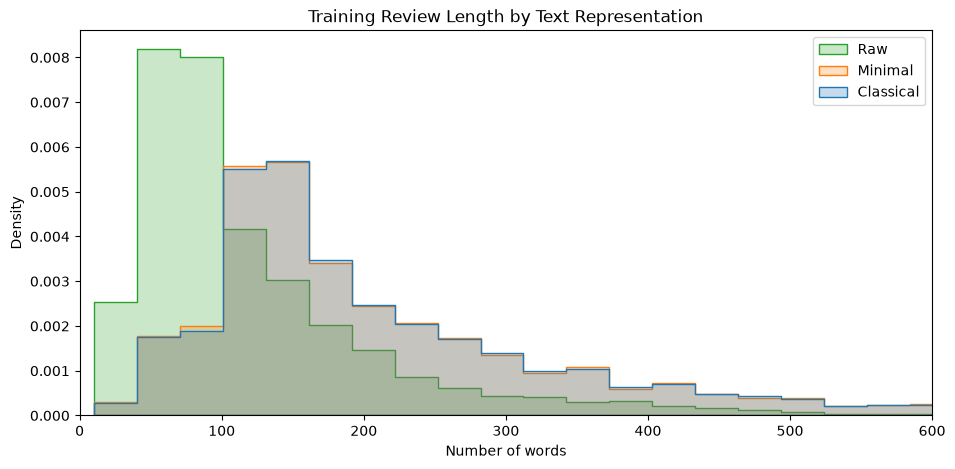

In [14]:
plt.figure(figsize=(11, 5))
sns.histplot(
    train_df[["raw_word_count", "minimal_word_count", "classical_word_count"]],
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)
plt.xlim(0, 600)
plt.title("Training Review Length by Text Representation")
plt.xlabel("Number of words")
plt.ylabel("Density")
plt.legend(["Raw", "Minimal", "Classical"])
plt.show()

<h3 style="color:#009E73;">How to Interpret the Audit</h3>

The expected pattern is:

- `minimal_text` remains close to the raw review because it only standardizes formatting.
- `classical_text` becomes shorter and uses a smaller vocabulary.
- Neither representation creates missing or empty reviews.
- Negation remains available in `classical_text`.

A smaller vocabulary is not automatically better. Day 2 must test whether the reduction improves validation F1.

In [15]:
comparison_sample = train_df.sample(5, random_state=SEED)[
    ["sentiment", "text", "minimal_text", "classical_text"]
]

pd.set_option("display.max_colwidth", 300)
display(comparison_sample)

,sentiment,text,minimal_text,classical_text
555,Negative,The Good:<br /><br />Effective color scheme. Good costumes. Top notch set production. Well detailed CGI buildings and vehicles.<br /><br />The Bad:<br /><br />Horrible mixture of actors with all CGI actors mixes Fifth Element with Final Fantasy. The CGI actors look even worse than video games fr...,the good: effective color scheme. good costumes. top notch set production. well detailed cgi buildings and vehicles. the bad: horrible mixture of actors with all cgi actors mixes fifth element with final fantasy. the cgi actors look even worse than video games from a few years ago. flawed logic....,good effective color scheme good costume top notch set production well detailed cgi building vehicle bad horrible mixture actor cgi actor mix fifth element final fantasy cgi actor look even bad video game year ago flaw logic giant pyramid show no one research no one really even question no expla...
3491,Positive,"Jim Carrey is back to much the same role that he played in The Mask, a timid guy who is trying to get ahead in the world but who seems to be plagued with bad luck. Even when he tries to help a homeless guy from being harassed by a bunch of hoodlums (and of course they have to be Mexican, obvious...","jim carrey is back to much the same role that he played in the mask, a timid guy who is trying to get ahead in the world but who seems to be plagued with bad luck. even when he tries to help a homeless guy from being harassed by a bunch of hoodlums (and of course they have to be mexican, obvious...",jim carrey back much role play mask timid guy try get ahead world seem plague bad luck even try help homeless guy harass bunch hoodlum course mexican obviously good towards fellow man backfire case not hard predict handful angry hoodlum like movie suggest thing like not ignore remind episode mic...
527,Positive,"A weird, witty and wonderful depiction of family life! Writer Andrew Marshall has written something that is funny, foreboding and occasionally frightening! Yes, don't be fooled by 2point4 children's cheerful tune and bubbly characters; the show has a dark side, and at times can be quite chilling...","a weird, witty and wonderful depiction of family life! writer andrew marshall has written something that is funny, foreboding and occasionally frightening! yes, don't be fooled by 2point4 children's cheerful tune and bubbly characters; the show has a dark side, and at times can be quite chilling...",weird witty wonderful depiction family life writer andrew marshall write something funny forebode occasionally frighten yes not fool point child cheerful tune bubbly character show dark side time quite chill good show not simplistic sitcom every character comic device case family instead charact...
3925,Positive,"Across the great divide which we call understanding, there is still much we do not know about that which was explained by the early tribal Elders. In every instance, there is much concerning the dangers of knowing too much. Conversely, there are those who warn us of not preparing for what they w...","across the great divide which we call understanding, there is still much we do not know about that which was explained by the early tribal elders. in every instance, there is much concerning the dangers of knowing too much. conversely, there are those who warn us of not preparing for what they w...",across great divide call understanding still much not know explain early tribal elder every instance much concern danger know much conversely warn u not prepare warn end time movie call last wave aboriginal native murder no apparent reason responsible arrest remain silent less disturb order thin...
2989,Negative,"If it wasn't for the performances of Barry Diamond and Art Evans as the clueless stoners, I would have no reason to recommend this to anyone.<br /><br />The plot centers around a 10 year high school reunion, which takes place in a supposed abandon high school(looks more like

<h2 style="color:#0072B2;">1.15 Saving Reusable Day 1 Outputs</h2>

Three files are saved so that Day 2 can preserve the exact Week 7 experiment split.

Each file contains:

- `text`: original review for traceability.
- `minimal_text`: natural-language version for LSTM and transformers.
- `classical_text`: normalized version for TF-IDF.
- `label`: numerical target.
- `sentiment`: readable target.

Day 2 must fit TF-IDF or any learned preprocessing component on the training file only.

In [16]:
output_directory = Path("outputs/week8_day1")
output_directory.mkdir(parents=True, exist_ok=True)

output_columns = [
    "text", "minimal_text", "classical_text", "label", "sentiment"
]

output_paths = {
    "Training": output_directory / "imdb_train_preprocessed.csv",
    "Validation": output_directory / "imdb_validation_preprocessed.csv",
    "Test": output_directory / "imdb_test_preprocessed.csv",
}

for split_name, dataframe in splits.items():
    dataframe[output_columns].to_csv(output_paths[split_name], index=False)
    print(f"Saved {split_name.lower()} data to: {output_paths[split_name]}")
    print("Rows:", len(dataframe))

Saved training data to: outputs/week8_day1/imdb_train_preprocessed.csv
Rows: 4000
Saved validation data to: outputs/week8_day1/imdb_validation_preprocessed.csv
Rows: 1000
Saved test data to: outputs/week8_day1/imdb_test_preprocessed.csv
Rows: 1000


<h2 style="color:#0072B2;">Day 1 Conclusion</h2>

This notebook completed all Day 1 requirements while extending the existing Week 7 project.

### Sprint Planning

The Sprint 3 goal and backlog were connected directly to the previous LSTM, DistilBERT, TF-IDF, and ensemble experiments.

### Reproducible Data

The exact Week 7 `4,000 / 1,000 / 1,000` split was reconstructed. Exact duplicates were removed before sampling, and normalized overlap was audited.

### Model-specific Preprocessing

Two representations were created instead of forcing one pipeline onto all models:

- Minimal text for LSTM and DistilBERT.
- Classical linguistic text for TF-IDF.

### Meaning Preservation

Negation words were protected, contracted negation was expanded, and assertions verified the behavior on difficult sentiment examples.

### Day 2 Handoff

Day 2 will compare TF-IDF on `minimal_text` versus `classical_text`, tune the representation using validation F1, examine important features, and compare the selected result with the Week 7 baseline. The test set will remain untouched until the final configuration is selected.

### Tools Used

NLTK • Hugging Face Datasets • Transformers • Scikit-learn • Pandas • NumPy • Matplotlib • Seaborn • Jupyter/Colab